In [1]:
import numpy as np
import spatialmath as sm
import spatialmath.base as smb
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

np.random.seed(42)

测试Bend & Twist的能量形式是否可以被距离的平方表示

In [24]:
# 定义两个单位四元数 q1 和 q2
q1 = np.array([1, 0, 0, 0])  # 示例四元数，替换为实际数值
q2 = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])  # 示例四元数，替换为实际数值

# 计算 q1 的共轭
q1_conj = smb.qconj(q1)

# 计算 q1 的共轭与 q2 的乘积
q_prod = smb.qqmul(q1_conj, q2)

# 提取乘积的虚部（x, y, z 部分）
omega = np.zeros(4)
# omega[1:] = q_prod[1:]
omega[:] = q_prod[:]
print(omega)

u1 = smb.qqmul(q1, omega/2)
u2 = smb.qqmul(q2, smb.qconj(omega/2))
print(u1)
print(u2)

[0.70710678 0.         0.         0.70710678]
[0.35355339 0.         0.         0.35355339]
[0.5 0.  0.  0. ]


斜率：[1.99989494]


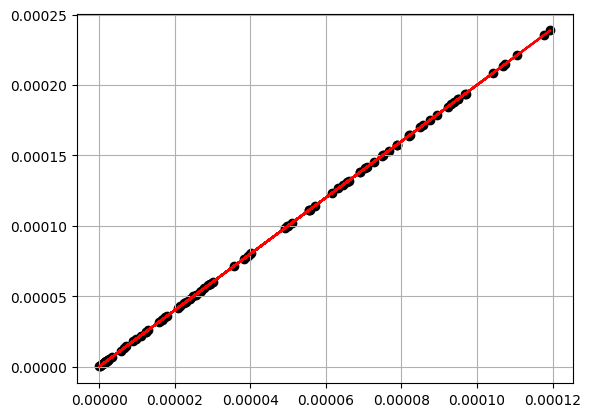

In [42]:
x_list = []
y_list = []
for i in range(100):
    theta1 = np.random.rand() * np.pi
    theta2 = theta1 + np.random.rand() * np.pi * 0.01

    y = np.sin((theta1-theta2)/2) ** 2
    x = (np.sin(theta1/2) - np.sin((theta1+theta2)/4)) ** 2 + (np.sin(theta2/2) - np.sin((theta1+theta2)/4)) ** 2 + \
        (np.cos(theta1/2) - np.cos((theta1+theta2)/4)) ** 2 + (np.cos(theta2/2) - np.cos((theta1+theta2)/4)) ** 2
    x_list.append(x)
    y_list.append(y)

x_np = np.array(x_list).reshape(-1, 1)
y_np = np.array(y_list).reshape(-1, 1)

model = LinearRegression(fit_intercept=False)
model.fit(x_np, y_np)

# 获取斜率
k = model.coef_[0]
print(f'斜率：{k}')

y_fit = model.predict(x_np)
plt.scatter(x_np, y_np, c='k', label='Data Points')
plt.plot(x_np, y_fit, color='red')
plt.grid(True)

In [2]:
def angular_velocities(q1, q2, dt):
    return (2 / dt) * np.array([
        q1[0]*q2[1] - q1[1]*q2[0] - q1[2]*q2[3] + q1[3]*q2[2],
        q1[0]*q2[2] + q1[1]*q2[3] - q1[2]*q2[0] - q1[3]*q2[1],
        q1[0]*q2[3] - q1[1]*q2[2] + q1[2]*q2[1] - q1[3]*q2[0]])

In [5]:
q1 = np.array([1, 0, 0, 0])
q2 = np.array([np.cos(np.pi/100/4), 0, 0, 1/np.sqrt(np.pi/100/4)])
print(angular_velocities(q1, q2, 0.01))

[   0.            0.         2256.75833419]


测试Cosserat中的DiffPD中的梯度计算是否正确

In [4]:
# Finite Defference for Bend Constraint
finite_delta = 1.e-8
angle1_init, angle2_init = np.random.uniform(0, np.pi), np.random.uniform(0, np.pi)
print(f'angle1_init: {angle1_init}, angle2_init: {angle2_init}')
u1_init = np.array([np.cos(angle1_init/2), np.sin(angle1_init/2)])
u2_init = np.array([np.cos(angle2_init/2), np.sin(angle2_init/2)])
u_init = np.concatenate((u1_init, u2_init))

u_average_init = (u1_init + u2_init) / 2
u_average_norm_init = np.linalg.norm(u_average_init)
u_average_unit_init = u_average_init / u_average_norm_init
u_average_angle_init = np.array([np.cos((angle1_init+angle2_init)/4), np.sin((angle1_init+angle2_init)/4)])

Bp_bend_init = np.tile(u_average_unit_init, 2)

angle1_init: 2.9867570806801083, angle2_init: 2.2996267900669447


In [ ]:
J_bend = np.zeros((4, 4))
for i in range(4):
    u = u_init.copy()
    u[i] += finite_delta
    u1 = u[:2]
    u2 = u[2:]
    u1 = u1 / np.linalg.norm(u1)
    u2 = u2 / np.linalg.norm(u2)
    u_average = (u1 + u2) / 2
    u_average_unit = u_average / np.linalg.norm(u_average)
    Bp_bend = np.tile(u_average_unit, 2)
    J_bend[:, i] = (Bp_bend - Bp_bend_init) / finite_delta
print(f'Finite Difference:\n {J_bend}')
# 这种求解方法是错误的,因为u的模长必须为1,在归一化的时候,改变了每个分量上增加的`Finite Difference`的值

In [6]:
# 所以下面这种解析的方法也是错误的,没有包含模长为1的约束
bend_grad = np.zeros((4, 4))
tmp = np.eye(2) / u_average_norm_init - np.power(u_average_norm_init**2, -1.5) * np.outer(u_average_init, u_average_init)
bend_grad[0:2, 0:2] = tmp
bend_grad[2:4, 0:2] = tmp
bend_grad[0:2, 2:4] = tmp
bend_grad[2:4, 2:4] = tmp
print(f'Analytic Method:\n {bend_grad}')

Analytic Method:
 [[ 0.82780755 -0.48496419  0.82780755 -0.48496419]
 [-0.48496419  0.28411224 -0.48496419  0.28411224]
 [ 0.82780755 -0.48496419  0.82780755 -0.48496419]
 [-0.48496419  0.28411224 -0.48496419  0.28411224]]


In [19]:
# 正确的Finite Difference方法 for Bend Constraint
J_bend = np.zeros((2, 4))
angle1 = angle1_init + finite_delta
u_average = np.array([np.cos((angle1+angle2_init)/4), np.sin((angle1+angle2_init)/4)])
J_bend[:, 0] = (u_average-u_average_angle_init)/(np.cos(angle1/2)-np.cos(angle1_init/2))
J_bend[:, 1] = (u_average-u_average_angle_init)/(np.sin(angle1/2)-np.sin(angle1_init/2))
angle_2 = angle2_init + finite_delta
u_average = np.array([np.cos((angle1_init+angle_2)/4), np.sin((angle1_init+angle_2)/4)])
J_bend[:, 2] = (u_average-u_average_angle_init)/(np.cos(angle_2/2)-np.cos(angle2_init/2))
J_bend[:, 3] = (u_average-u_average_angle_init)/(np.sin(angle_2/2)-np.sin(angle2_init/2))
print(f'Finite Difference:\n {J_bend}')

bend_grad = np.zeros((2, 4))
du_star = np.array([-np.sin((angle1_init+angle2_init)/4) / 4, np.cos((angle1_init+angle2_init)/4) / 4])
du1 = np.array([-2/np.sin(angle1_init/2), 2/np.cos(angle1_init/2)])
du2 = np.array([-2/np.sin(angle2_init/2), 2/np.cos(angle2_init/2)])
bend_grad[:,0:2] = np.outer(du_star, du1)
bend_grad[:,2:4] = np.outer(du_star, du2)
print(f'Analytic Method:\n {bend_grad}')

Finite Difference:
 [[ 0.77737199 -0.51861147  0.43271379 -5.57816259]
 [-0.45541695  0.30382424 -0.2535018   3.26792043]]
Analytic Method:
 [[ 0.77737199 -0.51861148  0.4327138  -5.57816205]
 [-0.45541693  0.30382423 -0.25350179  3.26791996]]


In [11]:
# 在Bend constraint中,\theta=0的时候,解析的方法无法求解,因为分母为0
finite_delta = 1.e-6
angle1_init, angle2_init = 0, np.random.uniform(0, 2*np.pi)
u_average_init = np.array([np.cos((angle1_init+angle2_init)/4), np.sin((angle1_init+angle2_init)/4)])
angle1 = angle1_init + finite_delta
u_average = np.array([np.cos((angle1+angle2_init)/4), np.sin((angle1+angle2_init)/4)])
print(f'angle1: {angle1}, angle1 init: {angle1_init}')
print(f'{np.cos(angle1/2) - np.cos(angle1_init/2)}')
J = (u_average - u_average_init) / (np.cos(angle1/2) - np.cos(angle1_init/2))
print(f'J: {J}')

angle1: 1e-06, angle1 init: 0
-1.2501111257279263e-13
J: [1793223.70737123 -885233.09147425]


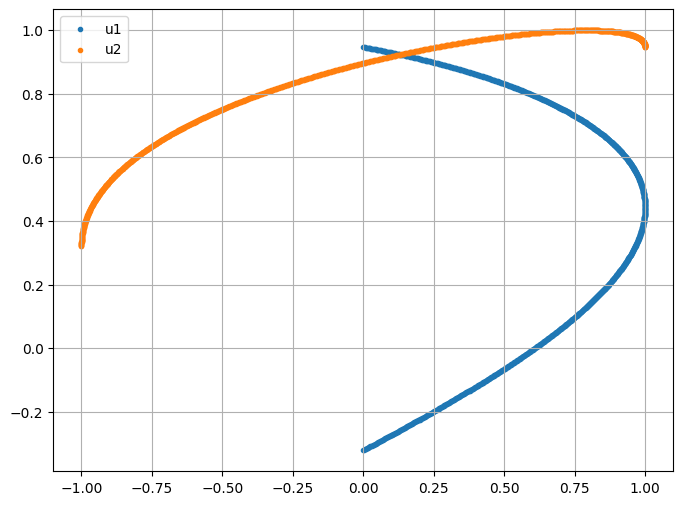

In [31]:
angle1 = np.linspace(-np.pi, np.pi, 1000)
u_average = np.array([np.cos((angle1+angle2_init)/4), np.sin((angle1+angle2_init)/4)])

fig = plt.figure(figsize=(8, 6), dpi=100)
ax = fig.add_subplot(111)

ax.scatter(np.cos(angle1/2), u_average[0], label='u1', marker='.')
ax.scatter(np.sin(angle1/2), u_average[1], label='u2', marker='.')
ax.legend()
ax.grid(True)

In [2]:
# Finite Difference for Stretch Constraint
finite_delta = 1.e-8
x1_init, x2_init = np.random.rand(2), np.random.rand(2)
x_init = np.concatenate((x1_init, x2_init))

distance_vec_init = x2_init - x1_init
distance_vec_unit_init = distance_vec_init / np.linalg.norm(distance_vec_init)
Bp_stretch_init = np.array([distance_vec_unit_init])

J_stretch = np.zeros((2, 4))
for i in range(4):
    u = x_init.copy()
    u[i] += finite_delta
    x1, x2 = u[:2], u[2:]
    distance_vec = x2 - x1
    distance_vec_unit = distance_vec / np.linalg.norm(distance_vec)
    J_stretch[:, i] = (np.array([distance_vec_unit]) - Bp_stretch_init) / finite_delta
print(f'Finite Difference:\n {J_stretch}')

Finite Difference:
 [[-1.6944798   0.05671497  1.6944798  -0.05671497]
 [ 0.05671494 -0.00189829 -0.05671499  0.00189827]]


In [3]:
stretch_grad = np.zeros((2, 4))
tmp = np.eye(2) / np.linalg.norm(distance_vec_init) - np.outer(distance_vec_init, distance_vec_init) / np.power(np.linalg.norm(distance_vec_init), 1.5)
stretch_grad[:, 0:2] = -tmp
stretch_grad[:, 2:4] = tmp
print(f'Analytic Method:\n {stretch_grad}')

Analytic Method:
 [[ 1.69551891 -0.02566928 -1.69551891  0.02566928]
 [-0.02566928  0.92945391  0.02566928 -0.92945391]]
